# **Telecom Customer Churn EDA**
We are exploring the Telecom Customer data, it contains info whether they have ported to other networks or not using the 'Churn' field.

We will have to do EDA and find insights and reasoning behind customer churn.

Lets start!!

In [2]:
# Import Required Libararies

#  (please ignore matplotlib/seaborn for now )

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#matplotlib inline
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

In [1]:
#Loading the dataset

df = pd.read_csv('telco_churn.csv')

In [3]:
# Preview Data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Data Inspection**

In [8]:
#  Rows/Cols Count
df.shape

(7043, 21)

In [9]:
# Columns DataTypes
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [10]:
# Statistical Summary about Numerical Columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# DataFrame Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **Data Quality Check**

In [ ]:
#Lets check the quality, looks like TotalCharges is not mapped to correct dtype

In [14]:
df['TotalCharges'].dtype

dtype('O')

In [13]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [15]:
#Coverting to Float

df['TotalCharges'] = df['TotalCharges'].astype('float')

ValueError: could not convert string to float: ' '

In [18]:
#Removing whitespaces, n using to numberic so that we can manuplate and do arthemetic ops
df['TotalCharges']=pd.to_numeric( df['TotalCharges'] , errors='coerce')

#Checking changed type
df['TotalCharges'].dtype

dtype('float64')

# **Data Imbalance Check**

In [19]:
#Lets check for churn
df['Churn'].head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


In [22]:
#Converting to Percentage values
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


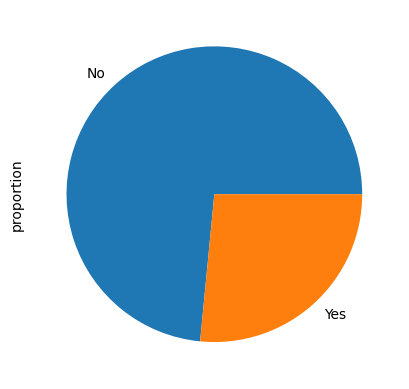

In [23]:
#Lets visualise n see
df['Churn'].value_counts(normalize=True).plot(kind='pie');

# **EDA Strategy**
------------------------
<pre>
We are going to split the DataFrame into 2 Sub DataFrame where

df_leavers = 'contains records of customers who left the network'

df_customers = 'contains records of existing  customer '

later we shall compare their habbits eg. spending habits/gender etc to find out the impact on Churning.

In [29]:
# Splitting the data into two groups: churned customers (leavers) and retained customers (exsting)
df_leavers = df[df.Churn == 'Yes']
df_customers = df[df.Churn == 'No']

In [25]:
df_leavers['Churn'].head()

,Churn
2,Yes
4,Yes
5,Yes
8,Yes
13,Yes


In [26]:
df_customers['Churn'].head()

,Churn
0,No
1,No
3,No
6,No
7,No


# **Univariate Analysis**
Univariate Analysis is analysis using Single Variable/Field/Column.

Target Field : MonthlyCharges

Objective: to understand the monthly spending habbits of people ( leavers vs customers)

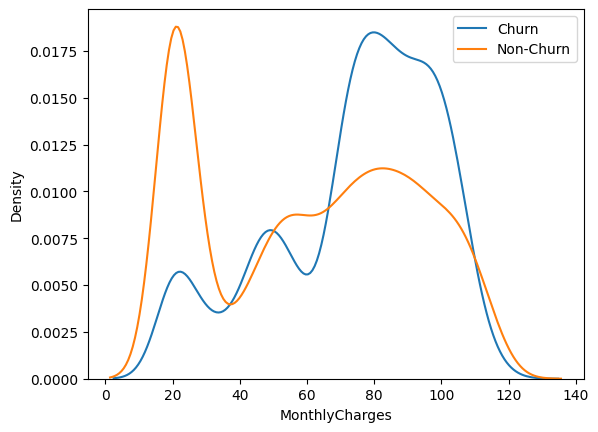

In [30]:
sns.distplot( df_leavers['MonthlyCharges'] ,label='Churn',hist=False)
sns.distplot( df_customers['MonthlyCharges'] ,label='Non-Churn',hist=False)
plt.legend()
plt.show()

In [31]:
df_leavers.MonthlyCharges.mean()

np.float64(74.44133226324237)

# **Bivariate Analysis**
Bivariate Analysis uses 2 Fields/Columns for Analysis.

eg. Let us observe the distribution of Data by their ContractType and MonthlyCharges.

In [36]:
#Cheecking the different types of Contracts
df['Contract'].unique().tolist()

['Month-to-month', 'One year', 'Two year']

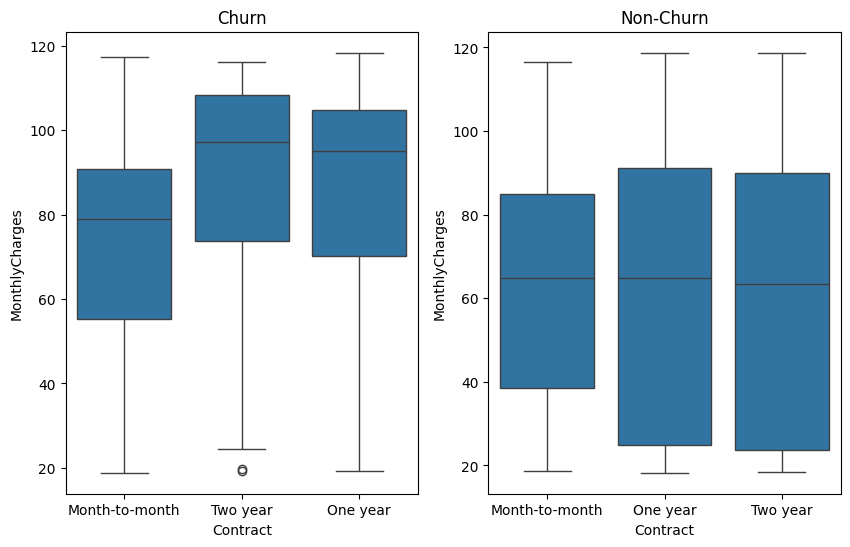

In [34]:
# Comparing MonthlyCharges across ContractType for leavers vs customers
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)

plt.title('Churn')

sns.boxplot(x='Contract',y='MonthlyCharges', data=df_leavers)



plt.subplot(1,2,2)

plt.title('Non-Churn')

sns.boxplot(x='Contract',y='MonthlyCharges', data=df_customers)

plt.show()

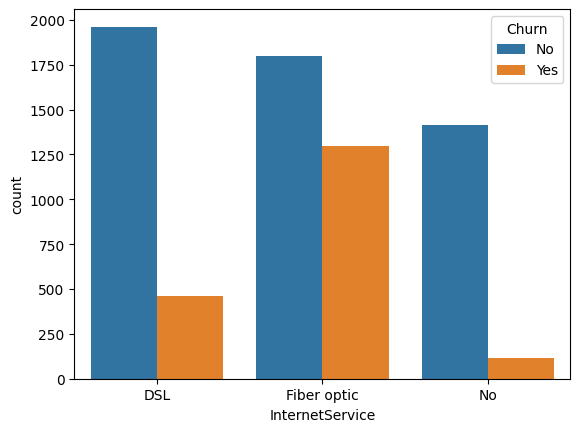

In [42]:
#Lets analyse for other attributes

# Churn by InternetService
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

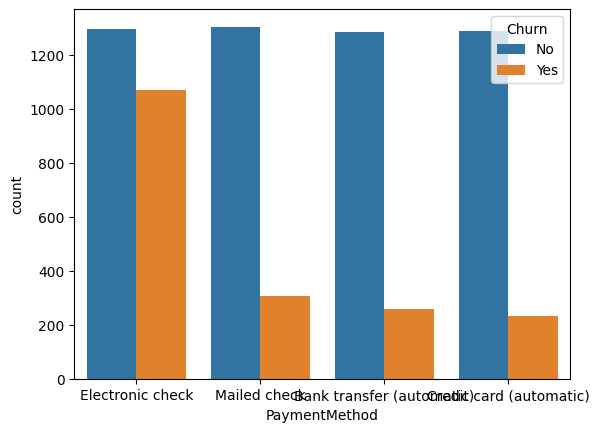

In [38]:
# Churn by PaymentMethod
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.show()


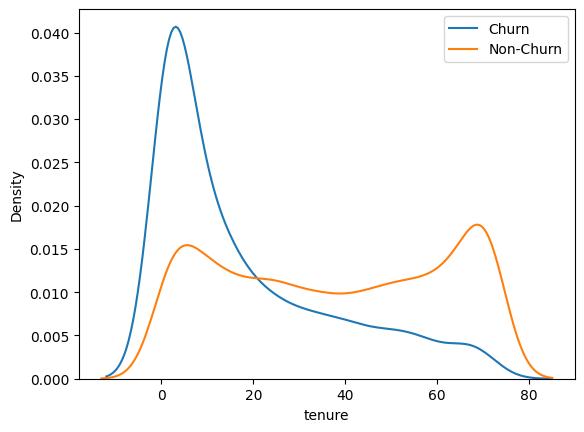

In [39]:
# Tenure distribution — leavers vs customers
sns.distplot(df_leavers['tenure'], label='Churn', hist=False)
sns.distplot(df_customers['tenure'], label='Non-Churn', hist=False)
plt.legend()
plt.show()

# **Key Insights**
Based on the EDA we can observe the following patterns in customer churn:


*   Churned customers tend to have higher monthly charges compared to retained customers.
*   Month-to-month contract customers show the highest churn, customers on longer contracts are much more stable.


*   Fiber optic internet users churn significantly more compared to DSL users. Customers with no internet service barely churn at all.
*   Electronic check as a payment method has the highest churn among all payment methods. Customers on automatic payments tend to stay longer.


*   New customers are at the highest risk — churned customers are heavily concentrated at low tenure values. The longer a customer stays, the less likely they are to leave.











**Next Steps:**


1.   The EDA gives us a good understanding of what drives churn.
2.   The next step would be to use these findings to build a classification model to predict which customers are likely to churn, which can help the take proactive steps to retain them. 🙂


